# Global CJ figure configuration

In [80]:
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable 

# Following options are dependant on https://github.com/chanjure/global_chanju.git
from global_chanju.paulplot.styles import nice_style
from global_chanju.paulplot.rc_setter import set_rc
from global_chanju.paulplot.rc_setter import get_rc
from global_chanju.utils.statistics import asym_err
from global_chanju.utils.statistics import f_bin
from global_chanju.paulplot.styles import base_ten

set_rc() # Setting global chanju plotting scheme

In [81]:
# Synthetic data to show examples

def poisson(k, l=4):
    return l**k * np.exp(-l) / sp.special.gamma(k+1)

# data
cuts = [10, 4, 1, 10, 8, 4, 2, 7, 7, 3, 3, 4]

# number of data points
n = len(cuts)

# Some data
y_data, x_bins = np.histogram(cuts)
x_data = 0.5*(x_bins + np.roll(x_bins, shift=1))[1:]
popt, pcov = sp.optimize.curve_fit(poisson, x_data, y_data)

/var/folders/60/czw76d8517j1d6_lrysbn7xc0000gn/T/ipykernel_11117/2045847818.py:4: RuntimeWarning: invalid value encountered in power
  return l**k * np.exp(-l) / sp.special.gamma(k+1)


**A few global characteristics of the theme**

- The edges of each axis is clear. For example, if the figure is defined from $x \in (0,2)$, set xlim=(0,2), so that the ticks on the each end matches the edge of the figure.

- Ticks are inward

- For log plots, show both major and minor ticks.

- Font size and font style corresponds to default latex font and fontsize 10.

## 1. Figure and subfigures

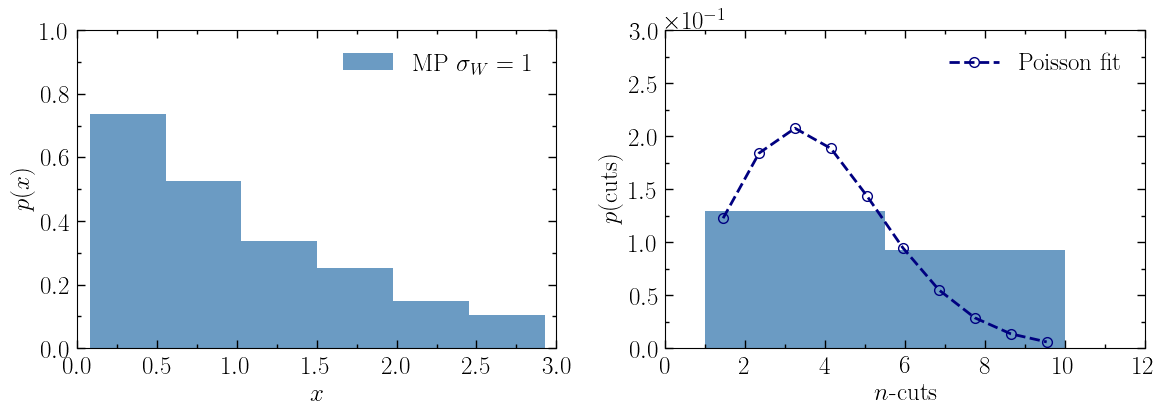

In [83]:
# Plotting empirical Marchenko-Pastur distribution
N = 100
D = 200
r = int(N/D)
sigma = 1./np.sqrt(D)
W = np.random.normal(0., sigma, (N, D)) # Rectangular Gaussian random matrix of size N x D
X = W @ W.T # Wishart matrix with aspect ratio r = N/D and sigma = 1.

x = np.linalg.eigvals(X) # Eigenvalues of X

set_rc(scale=1.) # Sets relative figure scale.
# scale=1. Corresponds to the fontsize 10 in the latex file.

# Plot eigenvalues
n_fig = 2 # Number of panels in the figure.

# Figure size is set by global parameter set_rc()
fig, axs = plt.subplots(
    1, n_fig, 
    figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r'])
)
# get_rc()['W'] gives the standard width
# get_rc()['r'] gives the standard aspect ratio

y_plot = x.flatten()
n_bin, xran, _, _ = f_bin(y_plot) # Calculates number of bins, range, and bin width using Diaconis method
axs[0].hist(
    y_plot, bins=n_bin, range=xran, 
    density=True,
    color='steelblue', alpha=0.8, # Standard theme for histogram, 
    label=r"MP $\sigma_W = 1$"
)

axs[0].legend(loc='upper right')

# Every style setting is done here
nice_style(
    axs[0],
    xlim=(0, 3), ylim=(0, 1),
    xlabel=r"$x$", ylabel=r"$p(x)$"
)

y_hist = np.array(cuts).flatten()
n_bin, xran, _, _ = f_bin(y_hist)
axs[1].hist(
    y_hist, bins=n_bin, range=xran,
    density=True,
    color='steelblue', alpha=0.8
)

axs[1].plot(
    x_data, poisson(x_data, l=popt[0]),
    color='navy', ls='--', lw=2,
    label=r"Poisson fit"
)

axs[1].legend(loc='upper right')

nice_style(
    axs[1],
    xlim=(0, 12), ylim=(0, 0.3),
    xlabel=r"$n$-cuts", ylabel=r"$p$(cuts)"
)


plt.show()

## 2. Square plots

- The max and min of the colourbar should match the end of the colourbar

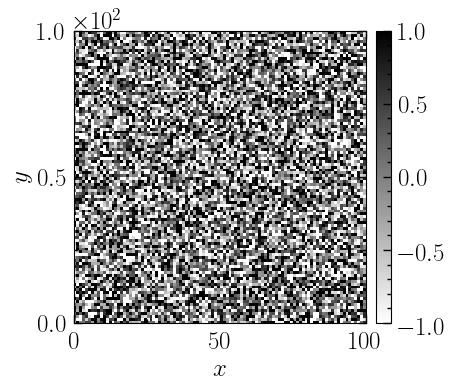

In [84]:
n_fig = 1 # Number of panels in the figure.

# Figure size is set by global parameter set_rc()
fig, axs = plt.subplots(
    1, n_fig, 
    figsize=(n_fig*get_rc()['W']*get_rc()['r'], get_rc()['W']*get_rc()['r']) # width and height are equal
)

img = np.random.normal(0, 1., (N, N))
im = axs.pcolor(
    img, 
    cmap='binary',
    vmin=-1, vmax=1 # Make sure the edge of the colorbar is clear.
)

axs.set_aspect("equal", adjustable="box") # Make it more square

nice_style(
    axs,
    xticks=[0, 50, 100], yticks=[0, 50, 100],
    xlabel=r"$x$", ylabel=r"$y$"
)

divider = make_axes_locatable(axs)
cax = divider.append_axes("right", size="5%", pad=0.1)

cb = fig.colorbar(im, cax=cax)

# plt.savefig("./example.pdf", bbox_inches="tight") # Use bbox_inches="tight" setting when saving

plt.show()

## 3. Multiple consecutive lines

- For multiple lines, use gradual colorscheme, here for example inferno. Preferably, they should be distinguishable in grayscale, i.e. the lighness should be linearly sequential.
- Use different line style and marker for each lines. => This is automatically done by declaring set_rc().

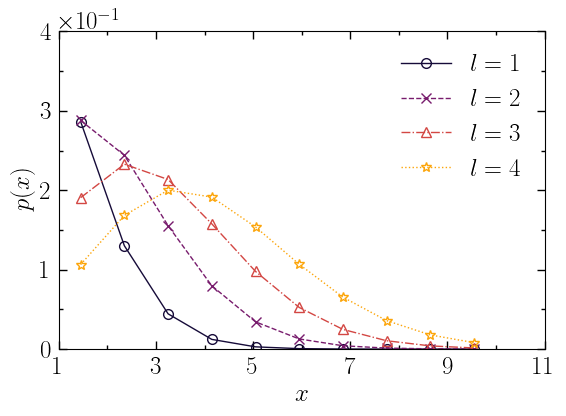

In [85]:
L_list = [1, 2, 3, 4]
cmap = plt.cm.inferno(np.linspace(0.1, 0.8, len(L_list)))

# Plot eigenvalues
n_fig = 1 # Number of panels in the figure.

# Figure size is set by global parameter set_rc()
fig, axs = plt.subplots(
    1, n_fig, 
    figsize=(n_fig*get_rc()['W'], get_rc()['W']*get_rc()['r'])
)

for i, l in enumerate(L_list):
    axs.plot(
        x_data, poisson(x_data, l),
        color=cmap[i],
        label=r"$l = %d$"%(l)
    )
    
axs.legend(loc="upper right")

nice_style(
    axs,
    xlim=(1, 10), ylim=(0, 0.4),
    xlabel=r"$x$", ylabel=r"$p(x)$",
    xticks=[1, 3, 5, 7, 9, 11]
)

plt.show()